In [2]:
!pip install rioxarray geopandas cftime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.1 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


Mencoba membuka file: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/2026/2026_02/chirps-v3.0.rnl.2026.02.23.nc


/tmp/ipykernel_57/2456216849.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


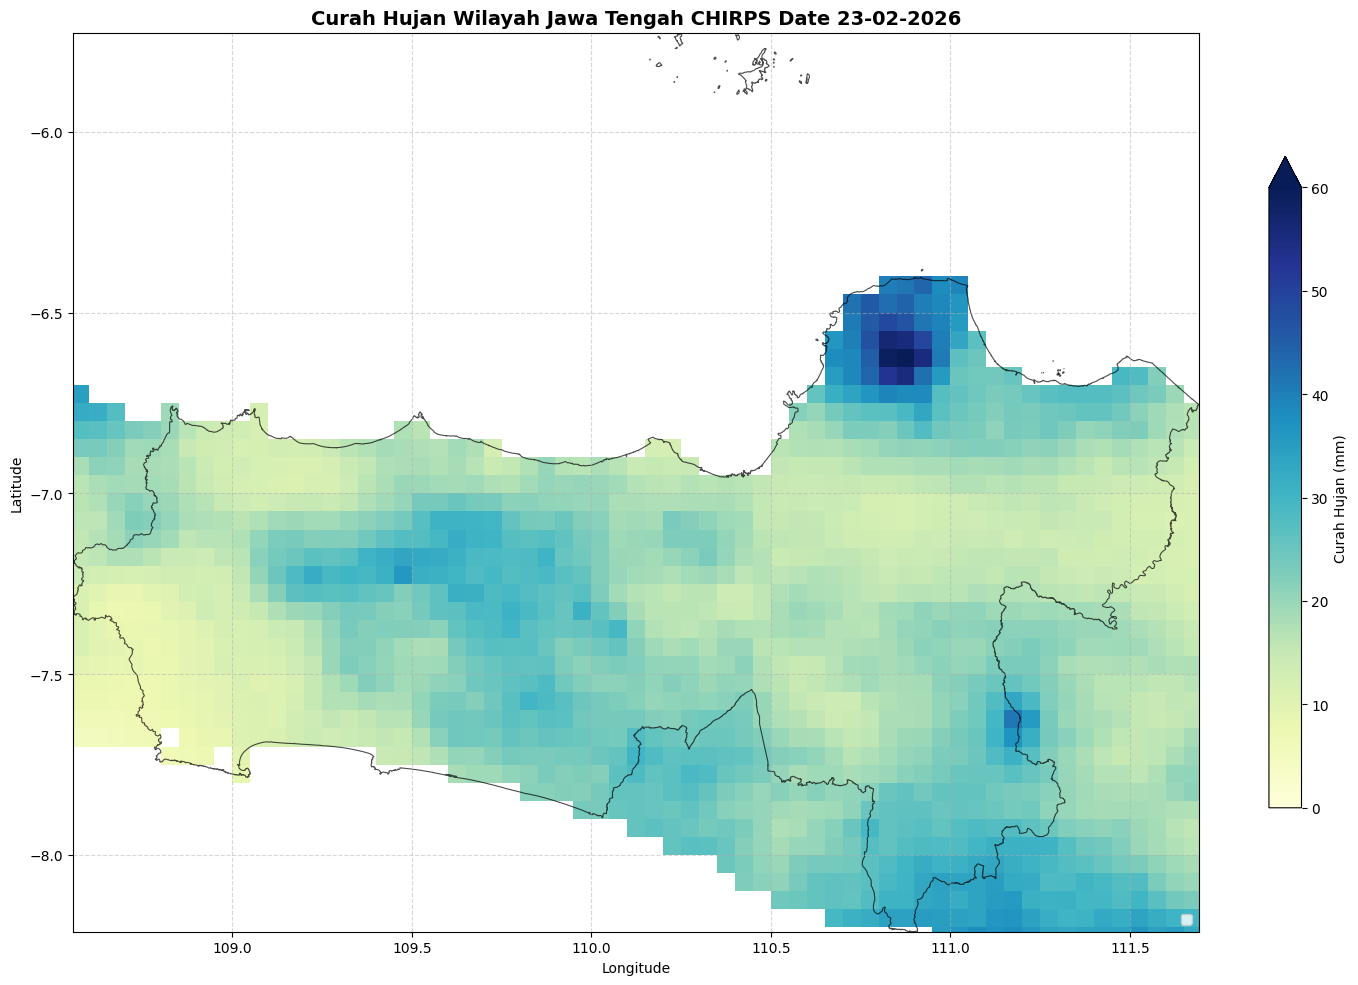

In [16]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PERSIAPAN DATA (GEOJSON & NETCDF)
# ==========================================
year = 2026
month = 2
day = 23

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "Jawa Tengah.geojson"
)

# --- PERBAIKAN DIREKTORI DI SINI ---
# Mengikuti pola: .../CHIRPS/2007/chirps-v3.0.rnl.2007.01.01.nc
file_nc = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
    f"{year}", f"{year}_{month:02d}", f"chirps-v3.0.rnl.{year}.{month:02d}.{day:02d}.nc"
)

print(f"Mencoba membuka file: {file_nc}")

# Pastikan file ada sebelum dibuka
if not os.path.exists(file_nc):
    print(f"⚠️ ERROR: File tidak ditemukan di {file_nc}")
else:
    gdf = gpd.read_file(file_geojson)

    # Buka file NetCDF
    da_global = rioxarray.open_rasterio(file_nc, masked=True).squeeze()

    # Safety Check: Pastikan NetCDF terbaca CRS-nya.
    if da_global.rio.crs is None:
        da_global.rio.write_crs("EPSG:4326", inplace=True)

    # ==========================================
    # 2. PENYELARASAN CRS
    # ==========================================
    if gdf.crs != da_global.rio.crs:
        gdf = gdf.to_crs(da_global.rio.crs)

    # ==========================================
    # 3. CLIPPING (Bounding Box)
    # ==========================================
    batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds
    da_kebumen = da_global.rio.clip_box(
        minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
    )

    # ==========================================
    # 4. VISUALISASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 10))

    # Plot Raster CHIRPS
    da_kebumen.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmax=60,
        vmin=0, 
        cbar_kwargs={'label': 'Curah Hujan (mm)', 'shrink': 0.7}
    )

    # Plot Garis Tepi GeoJSON
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.7)

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    title = f'Curah Hujan Wilayah Jawa Tengah CHIRPS Date {day:02d}-{month:02d}-{year}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

Mencoba membuka file: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/2026/2026_01/chirps-v3.0.rnl.2026.01.01.nc


/tmp/ipykernel_57/718282905.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


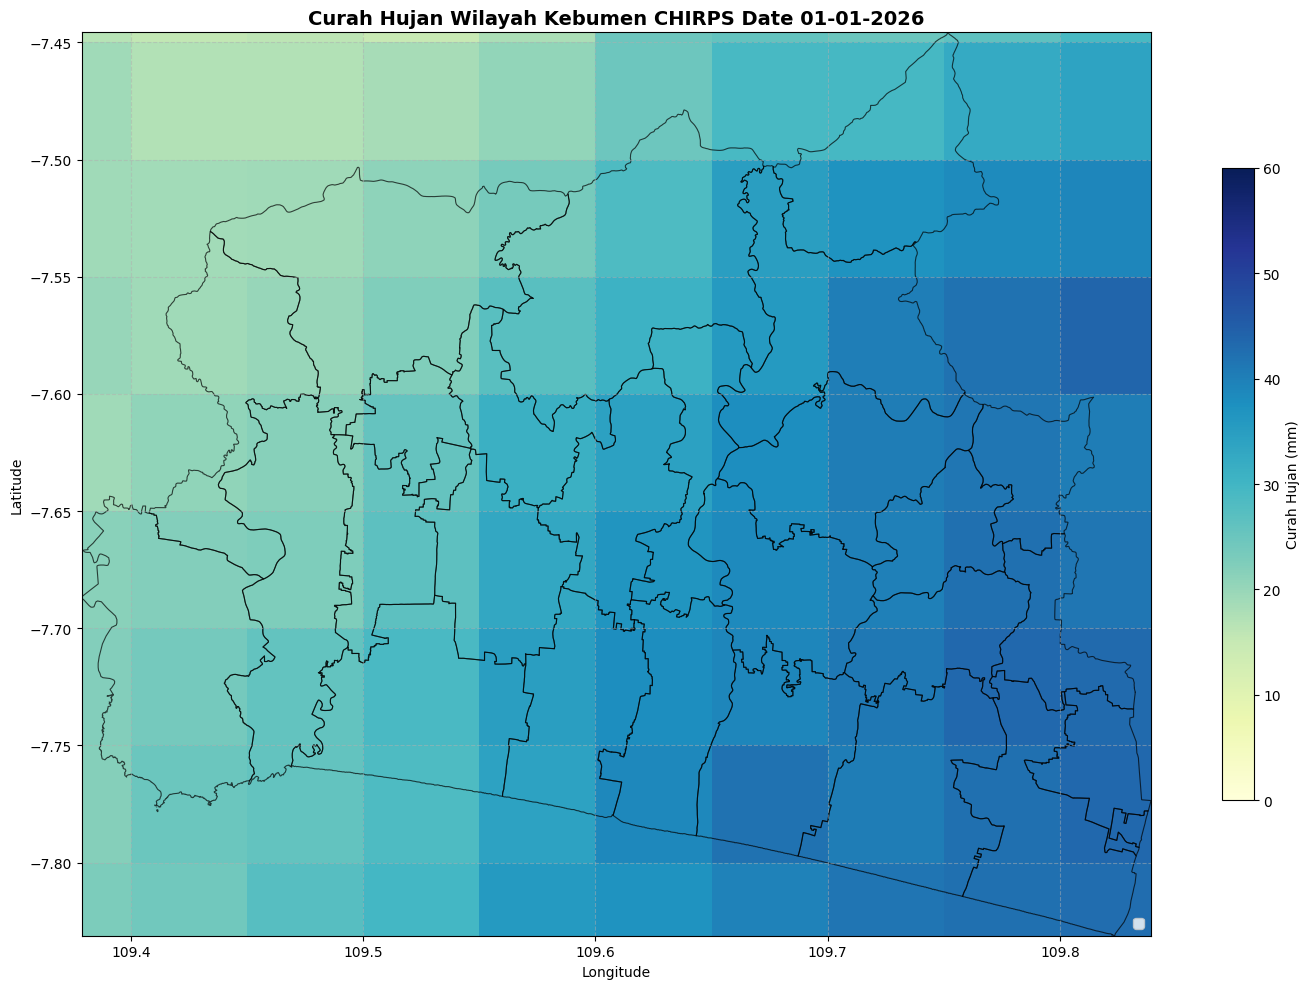

In [4]:
import os
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PERSIAPAN DATA (GEOJSON & NETCDF)
# ==========================================
year = 2026
month = 1
day = 1

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "33.05_kecamatan.geojson"
)

# --- PERBAIKAN DIREKTORI DI SINI ---
# Mengikuti pola: .../CHIRPS/2007/chirps-v3.0.rnl.2007.01.01.nc
file_nc = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
    f"{year}", f"{year}_{month:02d}", f"chirps-v3.0.rnl.{year}.{month:02d}.{day:02d}.nc"
)

print(f"Mencoba membuka file: {file_nc}")

# Pastikan file ada sebelum dibuka
if not os.path.exists(file_nc):
    print(f"⚠️ ERROR: File tidak ditemukan di {file_nc}")
else:
    gdf = gpd.read_file(file_geojson)

    # Buka file NetCDF
    da_global = rioxarray.open_rasterio(file_nc, masked=True).squeeze()

    # Safety Check: Pastikan NetCDF terbaca CRS-nya.
    if da_global.rio.crs is None:
        da_global.rio.write_crs("EPSG:4326", inplace=True)

    # ==========================================
    # 2. PENYELARASAN CRS
    # ==========================================
    if gdf.crs != da_global.rio.crs:
        gdf = gdf.to_crs(da_global.rio.crs)

    # ==========================================
    # 3. CLIPPING (Bounding Box)
    # ==========================================
    batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds
    da_kebumen = da_global.rio.clip_box(
        minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
    )

    # ==========================================
    # 4. VISUALISASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(15, 10))

    # Plot Raster CHIRPS
    da_kebumen.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmax=60,
        vmin=0, 
        cbar_kwargs={'label': 'Curah Hujan (mm)', 'shrink': 0.7}
    )

    # Plot Garis Tepi GeoJSON
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.7)

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    title = f'Curah Hujan Wilayah Kebumen CHIRPS Date {day:02d}-{month:02d}-{year}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

Mencari data di: /kaggle/input/datasets/jerismeteo/chirps-kebumen/data/CHIRPS/2026/2026_03/chirps-v3.0.rnl.2026.03.*.nc
Ditemukan 31 file NetCDF untuk Bulan 03 Tahun 2026.
Memulai proses ekstraksi dan pemotongan data...
Mengakumulasi curah hujan selama satu bulan...


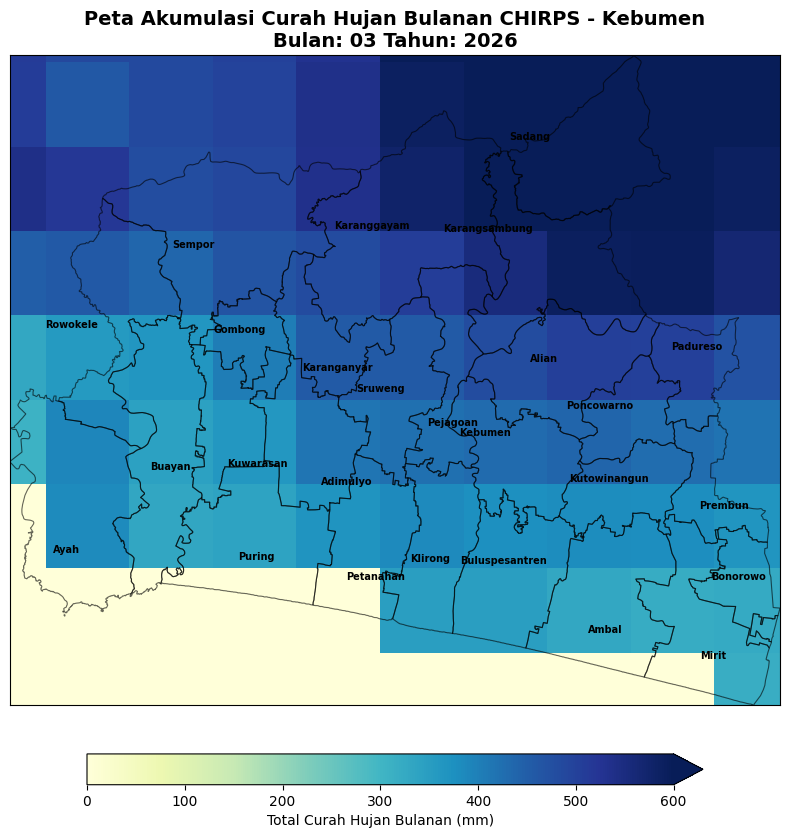

Selesai! Peta berhasil di-render dan disimpan sebagai Akumulasi_CHIRPS_Kebumen_2026_03.nc


In [9]:
import xarray as xr
import rioxarray
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import os

# ==========================================
# 1. PARAMETER WAKTU & LOKASI
# ==========================================
year = 2026  # Sesuaikan dengan tahun data Anda
month = 3    # Sesuaikan dengan bulan data Anda

# Melacak lokasi folder tempat script ini dijalankan
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# Menentukan lokasi GeoJSON (Asumsi berada di folder dataset Kaggle)
file_geojson = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "projek-downscale", "33.05_kecamatan.geojson"
)

# --- PERBAIKAN DIREKTORI (Hanya merujuk ke foldernya saja) ---
folder_chirps = os.path.join(
    BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
    f"{year}", f"{year}_{month:02d}"
)

# Buka GeoJSON dan ambil Bounding Box (Kotak Batas)
gdf = gpd.read_file(file_geojson)
batas_kiri, batas_bawah, batas_kanan, batas_atas = gdf.total_bounds

# ==========================================
# 2. MENCARI SEMUA FILE DI BULAN TERSEBUT
# ==========================================
# --- PERBAIKAN POLA PENCARIAN (Menyesuaikan dengan nama file NetCDF baru) ---
pola_pencarian = os.path.join(folder_chirps, f"chirps-v3.0.rnl.{year}.{month:02d}.*.nc")
daftar_file = glob.glob(pola_pencarian)
daftar_file.sort() # Pastikan urutan harinya benar dari tanggal 1 sampai akhir bulan

print(f"Mencari data di: {pola_pencarian}")
print(f"Ditemukan {len(daftar_file)} file NetCDF untuk Bulan {month:02d} Tahun {year}.")

if len(daftar_file) == 0:
    print("⚠️ Peringatan: Tidak ada file yang ditemukan. Pastikan path direktori sudah benar!")
else:
    # ==========================================
    # 3. LOOPING: MEMBACA DAN MEMOTONG PER HARI
    # ==========================================
    print("Memulai proses ekstraksi dan pemotongan data...")
    data_harian_terpotong = []

    # Kita buka file global, potong ke Kebumen, lalu simpan potongan kecilnya saja ke RAM
    for file in daftar_file:
        da_hari_ini = rioxarray.open_rasterio(file, masked=True).squeeze()
        
        # Safety Check: Paksakan CRS ke WGS84 jika NetCDF kehilangan atribut spasialnya
        if da_hari_ini.rio.crs is None:
            da_hari_ini.rio.write_crs("EPSG:4326", inplace=True)
        
        # Samakan CRS jika GeoJSON berbeda dengan data raster
        if file == daftar_file[0] and gdf.crs != da_hari_ini.rio.crs:
            gdf = gdf.to_crs(da_hari_ini.rio.crs)
        
        # Potong menggunakan clip_box
        da_potongan = da_hari_ini.rio.clip_box(
            minx=batas_kiri, miny=batas_bawah, maxx=batas_kanan, maxy=batas_atas
        )
        
        # Masukkan hasil potongan ke dalam list (keranjang)
        data_harian_terpotong.append(da_potongan)
        
        # Tutup file global untuk membebaskan memori
        da_hari_ini.close()

    # ==========================================
    # 4. PROSES AKUMULASI (PENJUMLAHAN BULANAN)
    # ==========================================
    print("Mengakumulasi curah hujan selama satu bulan...")
    # Gabungkan potongan harian menjadi satu dimensi 'time'
    da_gabungan = xr.concat(data_harian_terpotong, dim='time')

    # Jumlahkan dari atas ke bawah (menembus dimensi waktu)
    da_akumulasi_bulanan = da_gabungan.sum(dim='time', skipna=True)

    # ==========================================
    # 5. VISUALISASI PETA AKUMULASI
    # ==========================================
    fig, ax = plt.subplots(figsize=(8, 10))

    # Plot Raster Akumulasi CHIRPS
    da_akumulasi_bulanan.plot(
        ax=ax, 
        cmap='YlGnBu', 
        vmin=0, 
        vmax=600, # Batas diturunkan sedikit ke 600 agar gradasi warna lebih terlihat
        cbar_kwargs={
            'label': 'Total Curah Hujan Bulanan (mm)', 
            'orientation': 'horizontal', 
            'pad': 0.05, 
            'shrink': 0.8
        }
    )

    # Plot Garis Tepi GeoJSON 
    gdf.plot(ax=ax, facecolor="none", edgecolor='black', linewidth=0.8, alpha=0.6)

# Plot Label Kecamatan (Telah disesuaikan mendekati titik Kantor Kecamatan / Pusat Kota)
    koordinat_kecamatan = {
        'Adimulyo': (109.5804, -7.6987), 
        'Alian': (109.6979, -7.6256),
        'Ambal': (109.7345, -7.7865), 
        'Ayah': (109.4124, -7.7391),
        'Bonorowo': (109.8142, -7.7551), 
        'Buayan': (109.4746, -7.6895),
        'Buluspesantren': (109.6738, -7.7456), 
        'Gombong': (109.5161, -7.6083),
        'Karanganyar': (109.5744, -7.6309), 
        'Karanggayam': (109.5951, -7.5469),
        'Karangsambung': (109.6644, -7.5484), 
        'Kebumen': (109.6631, -7.6698),
        'Klirong': (109.6301, -7.7441), 
        'Kutowinangun': (109.7369, -7.6966),
        'Kuwarasan': (109.5268, -7.6881), 
        'Mirit': (109.7994, -7.8016),
        'Padureso': (109.7892, -7.6186), 
        'Pejagoan': (109.6437, -7.6634),
        'Petanahan': (109.5971, -7.7548), 
        'Poncowarno': (109.7313, -7.6536),
        'Prembun': (109.8055, -7.7126), 
        'Puring': (109.5264, -7.7431),
        'Rowokele': (109.4158, -7.6053), 
        'Sadang': (109.6896, -7.4938),
        'Sempor': (109.4883, -7.5581), 
        'Sruweng': (109.6006, -7.6433)
    }
    for nama_kec, (lon, lat) in koordinat_kecamatan.items():
        ax.text(
            lon, lat, nama_kec, 
            fontsize=7, 
            ha='center', va='center', 
            color='black', 
            fontweight='bold',
        )

    # Kunci Ukuran Kanvas
    ax.set_xlim(batas_kiri, batas_kanan)
    ax.set_ylim(batas_bawah, batas_atas)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

    title = f'Peta Akumulasi Curah Hujan Bulanan CHIRPS - Kebumen\nBulan: {month:02d} Tahun: {year}'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # Menyimpan hasil akumulasi menjadi file NetCDF (bukan TIF, agar waktu dan metadata aman)
    output_filename = f"Akumulasi_CHIRPS_Kebumen_{year}_{month:02d}.nc"
    da_akumulasi_bulanan.to_netcdf(output_filename)
    print(f"Selesai! Peta berhasil di-render dan disimpan sebagai {output_filename}")

In [18]:
import xarray as xr
import pandas as pd
import glob
import os

# ==========================================
# 1. PARAMETER WAKTU & TARGET KOORDINAT
# ==========================================
tahun_awal = 2000
tahun_akhir = 2026

# Koordinat Pusat Kabupaten Kebumen (Silakan ubah sesuai titik stasiun IoT Anda)
lat_target = -7.668
lon_target = 109.651

# Melacak lokasi folder Kaggle
cwd = os.getcwd()
BASE_DIR = "/kaggle" if "/kaggle/" in cwd or cwd == "/kaggle" else cwd

# ==========================================
# 2. MENCARI SEMUA FILE .nc (RENTANG TAHUN)
# ==========================================
semua_file = []

for year in range(tahun_awal, tahun_akhir + 1):
    # Path mengikuti struktur: .../CHIRPS/YYYY/YYYY_MM/*.nc
    pola_pencarian = os.path.join(
        BASE_DIR, "input", "datasets", "jerismeteo", "chirps-kebumen", "data", "CHIRPS", 
        str(year), f"{year}_*", "*.nc"
    )
    
    # Ambil semua file di tahun tersebut dan gabungkan ke list utama
    file_tahun_ini = glob.glob(pola_pencarian)
    semua_file.extend(file_tahun_ini)

# Pastikan urutan waktu dari 2000 sampai 2026 berurutan secara benar
semua_file.sort()

print(f"Ditemukan {len(semua_file)} file .nc dari tahun {tahun_awal} hingga {tahun_akhir}.")

if len(semua_file) == 0:
    print("⚠️ Peringatan: Tidak ada file yang ditemukan. Pastikan direktori sudah benar!")
else:
    # ==========================================
    # 3. BUKA SEMUA FILE SEBAGAI SATU DATASET
    # ==========================================
    print("Membaca dan menggabungkan ribuan file... (Mohon tunggu sebentar)")
    # Berkat format .nc yang sudah ada dimensi 'time', open_mfdataset akan otomatis
    # merajut ribuan file ini menjadi satu kubus data berdasarkan koordinat waktu.
    ds_combined = xr.open_mfdataset(semua_file, combine='by_coords')

    # ==========================================
    # 4. EKSTRAKSI SATU PIKSEL (POINT EXTRACTION)
    # ==========================================
    print(f"Mengekstrak deret waktu di koordinat: Lat {lat_target}, Lon {lon_target}...")
    
    # Karena kita menggunakan rioxarray sebelumnya, koordinat lintang bujur bernama 'y' dan 'x'
    point_data = ds_combined.sel(x=lon_target, y=lat_target, method="nearest")

    # ==========================================
    # 5. KONVERSI KE DATAFRAME & PEMBERSIHAN
    # ==========================================
    # Ubah format Array ke Tabel Pandas
    df_hasil = point_data.to_dataframe().reset_index()

    # Pada script konversi sebelumnya, kita memberi nama variabel hujannya "precipitation"
    if 'precipitation' in df_hasil.columns:
        df_hasil = df_hasil.rename(columns={'precipitation': 'curah_hujan'})
    
    # Buang kolom yang tidak perlu (seperti x, y, spatial_ref), sisakan Waktu & Hujan
    df_hasil = df_hasil[['time', 'curah_hujan']]
    
    # Pastikan data diurutkan dari yang paling lama ke paling baru
    df_hasil = df_hasil.sort_values('time')
    
    # Membulatkan nilai hujan 2 angka di belakang koma (opsional, agar rapi)
    df_hasil['curah_hujan'] = df_hasil['curah_hujan'].round(2)

    # ==========================================
    # 6. SIMPAN KE CSV
    # ==========================================
    nama_csv = f"timeseries_hujan_kebumen_{tahun_awal}_{tahun_akhir}.csv"
    
    # Simpan di working directory output Kaggle agar bisa di-download
    output_path = os.path.join(cwd, nama_csv) 
    df_hasil.to_csv(output_path, index=False)

    print(f"\n🎉 Selesai! Data {len(df_hasil)} hari berhasil diekstrak.")
    print(f"File tersimpan di: {output_path}")
    print("\nSampel 5 Data Pertama:")
    print(df_hasil.head())

Ditemukan 9587 file .nc dari tahun 2000 hingga 2026.
Membaca dan menggabungkan ribuan file... (Mohon tunggu sebentar)


/tmp/ipykernel_57/3648185188.py:50: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_combined = xr.open_mfdataset(semua_file, combine='by_coords')


Mengekstrak deret waktu di koordinat: Lat -7.668, Lon 109.651...

🎉 Selesai! Data 9587 hari berhasil diekstrak.
File tersimpan di: /kaggle/working/timeseries_hujan_kebumen_2000_2026.csv

Sampel 5 Data Pertama:
        time  curah_hujan
0 2000-01-01    14.460000
1 2000-01-02    26.540001
2 2000-01-03    14.610000
3 2000-01-04    17.540001
4 2000-01-05    25.520000
